# EDA — Capa Gold (Sprint 1)

Este notebook consulta las 4 tablas Gold y responde las preguntas analíticas B-1..B-4 del proyecto.

Correr dentro del contenedor `spark-iceberg`:

    docker compose exec spark-iceberg jupyter lab --ip=0.0.0.0 --no-browser

y abrir http://localhost:8888.


In [4]:
import sys
sys.path.insert(0, '/workspace/src')

from shared.config import (
    crear_spark_session,
    TBL_GOLD_AFLUENCIA_PM25,
    TBL_GOLD_ACCIDENTALIDAD,
    TBL_GOLD_ENCICLA_CLIMA,
    TBL_GOLD_CORREDORES_RIESGO,
)

spark = crear_spark_session('EDA-Gold')
spark.sparkContext.setLogLevel('ERROR')

## B-1 · Correlación PM2.5 / lluvia — afluencia Metro


In [5]:
import matplotlib.pyplot as plt

df = spark.table(TBL_GOLD_AFLUENCIA_PM25).toPandas()
print(f'Filas: {len(df):,}')
df.head(10)

Filas: 144


,anio,mes,linea,pasajeros_mes,pasajeros_promedio_dia,pm25_promedio_mes,precipitacion_total_mes_mm,corr_pm25_pasajeros,corr_precip_pasajeros,dias_observados
0,2024,11,A,28333908,944463.600000,NaN,NaN,NaN,NaN,30
1,2024,7,B,13714554,442404.967742,NaN,NaN,NaN,NaN,31
2,2024,9,K,4354827,145160.900000,NaN,NaN,NaN,NaN,30
3,2024,8,J,4213110,135906.774194,NaN,NaN,NaN,NaN,31
4,2024,5,J,4396008,141806.709677,NaN,NaN,NaN,NaN,31
5,2024,12,B,11618688,374796.387097,NaN,NaN,NaN,NaN,31
6,2024,4,J,4122129,137404.300000,NaN,NaN,NaN,NaN,30
7,2024,6,J,4172793,139093.100000,NaN,NaN,NaN,NaN,30
8,2024,6,K,4576719,152557.300000,NaN,NaN,NaN,NaN,30
9,2024,8,K,4683831,151091.322581,NaN,NaN,NaN,NaN,31


       corr_pm25_pasajeros  corr_precip_pasajeros
linea                                            
A                 0.034497                    NaN
B                 0.034584                    NaN
J                 0.029663                    NaN
K                 0.037234                    NaN


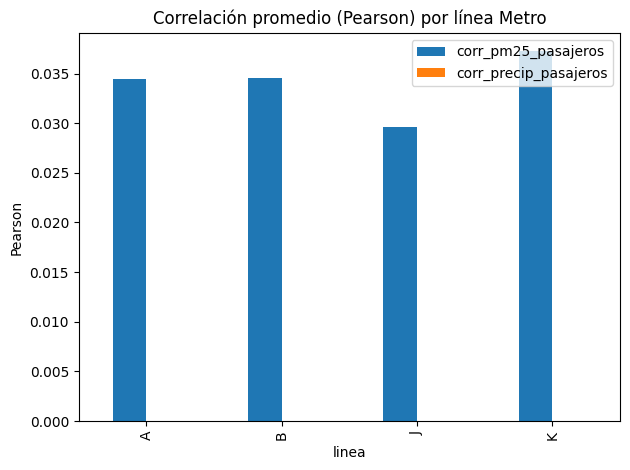

In [6]:
# Correlación promedio por línea
g = df.groupby('linea')[['corr_pm25_pasajeros','corr_precip_pasajeros']].mean()
print(g)
g.plot(kind='bar', title='Correlación promedio (Pearson) por línea Metro')
plt.ylabel('Pearson')
plt.tight_layout()
plt.show()

## B-2 · Accidentalidad por comuna


Top 10 comunas más severas en 2020:
                      comuna  con_heridos  con_muertos  solo_danos  indice_severidad
   Comuna 10 - La Candelaria         2002           30        1779            2329.9
         Comuna 5 - Castilla          926           10         566            1032.6
Comuna 11 - Laureles-Estadio          917            6         818            1028.8
          Comuna 7 - Robledo          804            6         488             882.8
        Comuna 15 - Guayabal          750            9         567             851.7
      Comuna 14 - El Poblado          731            7         742             840.2
         Comuna 4 - Aranjuez          749            7         328             816.8
           Comuna 16 - Belén          699            6         501             779.1
                           0          697            0         319             728.9
     Comuna 9 - Buenos Aires          569            3         259             609.9


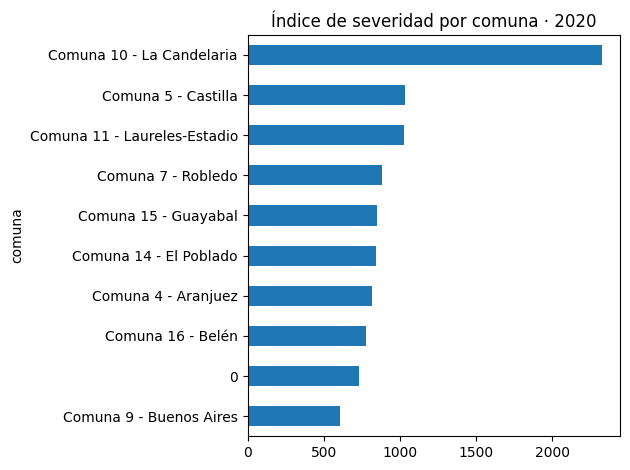

In [7]:
df2 = spark.table(TBL_GOLD_ACCIDENTALIDAD).toPandas()
ult = df2['anio'].max()
top10 = df2[df2['anio']==ult].nsmallest(10, 'ranking_severidad')[['comuna','con_heridos','con_muertos','solo_danos','indice_severidad']]
print(f'Top 10 comunas más severas en {ult}:')
print(top10.to_string(index=False))
ax = top10.set_index('comuna')['indice_severidad'].plot(kind='barh', title=f'Índice de severidad por comuna · {ult}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## B-3 · Demanda EnCicla vs clima


In [8]:
df3 = spark.table(TBL_GOLD_ENCICLA_CLIMA).toPandas()
# Comparar promedio de viajes por bin temperatura
g = df3[df3['bin_temperatura']!='sin_dato'].groupby('bin_temperatura')['viajes'].mean().sort_index()
print(g)
if len(g) > 0:
    g.plot(kind='bar', title='Viajes promedio EnCicla por rango de temperatura (°C)')
    plt.ylabel('Viajes / día')
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos de temperatura en el rango seleccionado (datos sintéticos)')

Series([], Name: viajes, dtype: float64)
Sin datos de temperatura en el rango seleccionado (datos sintéticos)


In [9]:
# Efecto de la lluvia
g2 = df3.groupby('llovio')['viajes'].mean()
print(g2)
if len(g2) >= 2:
    k = sorted(g2.index)
    sin_lluvia, con_lluvia = g2[k[0]], g2[k[1]]
    print(f'Promedio sin lluvia: {sin_lluvia:.1f}, con lluvia: {con_lluvia:.1f}')
    print(f'Caída relativa con lluvia: {(sin_lluvia-con_lluvia)/sin_lluvia*100:.1f}%')
else:
    print(f'Solo un valor de llovio en datos sintéticos: {g2}')

llovio
0    76.533333
Name: viajes, dtype: float64
Solo un valor de llovio en datos sintéticos: llovio
0    76.533333
Name: viajes, dtype: float64


## B-4 · Corredores de riesgo compuesto


                      comuna  vehiculos_total  con_muertos  con_heridos  score_riesgo
   Comuna 10 - La Candelaria          8942196          319        25022             3
Comuna 11 - Laureles-Estadio          9642532          115        11737             5
         Comuna 5 - Castilla          5752236          147        12809             6
          Comuna 7 - Robledo          2576656           69        12498             9
        Comuna 15 - Guayabal          5704368          119         9903            10
      Comuna 14 - El Poblado          7873312           70         8373            11
           Comuna 16 - Belén          1847932           70         9225            15
     Comuna 9 - Buenos Aires          1230192           44         5981            18
      Comuna 12 - La América          2169164           37         5132            18
         Comuna 4 - Aranjuez           184016          108         9060            20
  Comuna 6 - Doce de Octubre           514252         

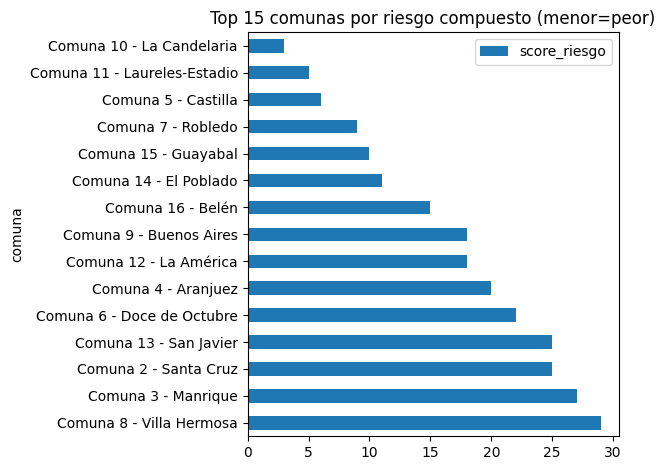

In [10]:
df4 = spark.table(TBL_GOLD_CORREDORES_RIESGO).toPandas().sort_values('score_riesgo').head(15)
print(df4[['comuna','vehiculos_total','con_muertos','con_heridos','score_riesgo']].to_string(index=False))
df4.plot(x='comuna', y='score_riesgo', kind='barh', title='Top 15 comunas por riesgo compuesto (menor=peor)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()